In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("../metherology_dataset.csv")

# Display basic info
print(df.head())
print(df.info())

# Handle missing values
df = df.dropna()

# Adjust column names based on your actual dataset
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour
    df['day'] = df['time'].dt.day
    df['month'] = df['time'].dt.month
    df['year'] = df['time'].dt.year
    df['dayofweek'] = df['time'].dt.dayofweek
    df = df.drop(columns=['time'])

# Define target column - adjust 'temperature' to your actual target column name
target_col = 'temperature_2m '

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Gradient Boosting Regressor
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluate using MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMean Absolute Error (MAE): {mae:.4f}")

# Feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 10 Feature Importances:")
print(feature_importance.sort_values(ascending=False).head(10))

  location              time  temperature_2m   relative_humidity_2m  \
0   Aveiro  2025-03-05T00:00             11.6                    79   
1   Aveiro  2025-03-05T01:00             11.2                    90   
2   Aveiro  2025-03-05T02:00             11.1                    90   
3   Aveiro  2025-03-05T03:00             10.4                    94   
4   Aveiro  2025-03-05T04:00              9.9                    95   

   dew_point_2m   rain   cloud_cover   cloud_cover_low   cloud_cover_mid   \
0            8.1    0.0            31                 0                31   
1            9.6    0.0            87                 9                85   
2            9.6    0.0            93                 0                93   
3            9.4    0.0            89                 0                89   
4            9.1    0.0            23                 0                23   

   cloud_cover_highh  wind_speed_10m   wind_direction_10m   wind_gusts_10m   \
0                  0           

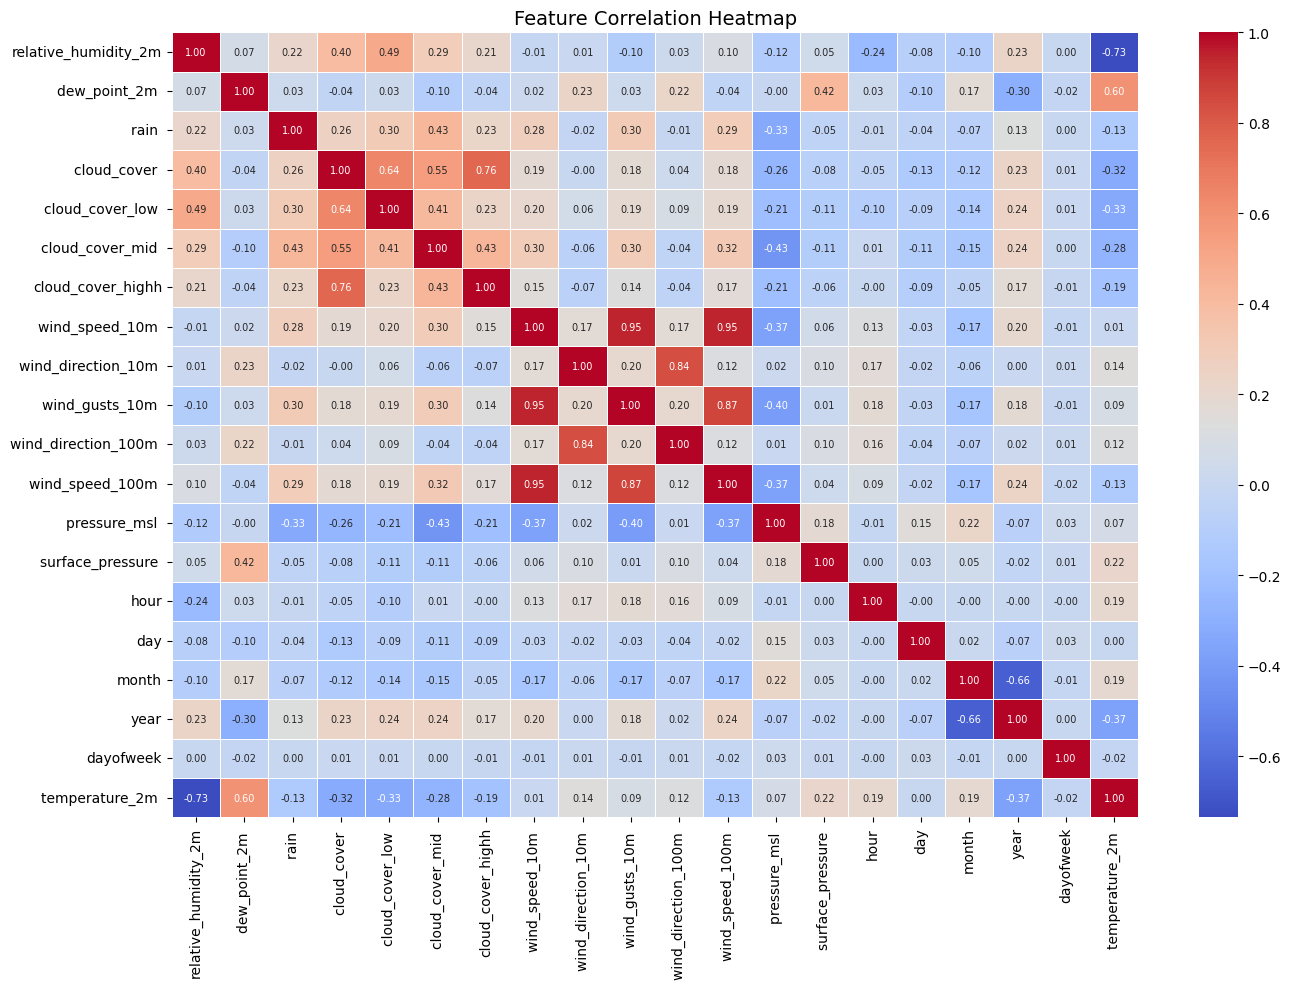

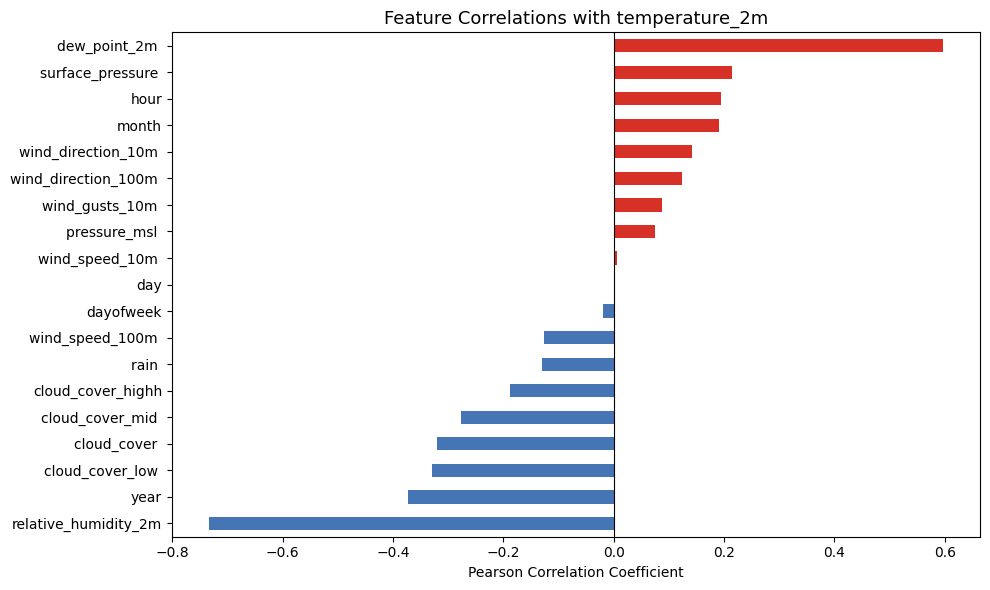

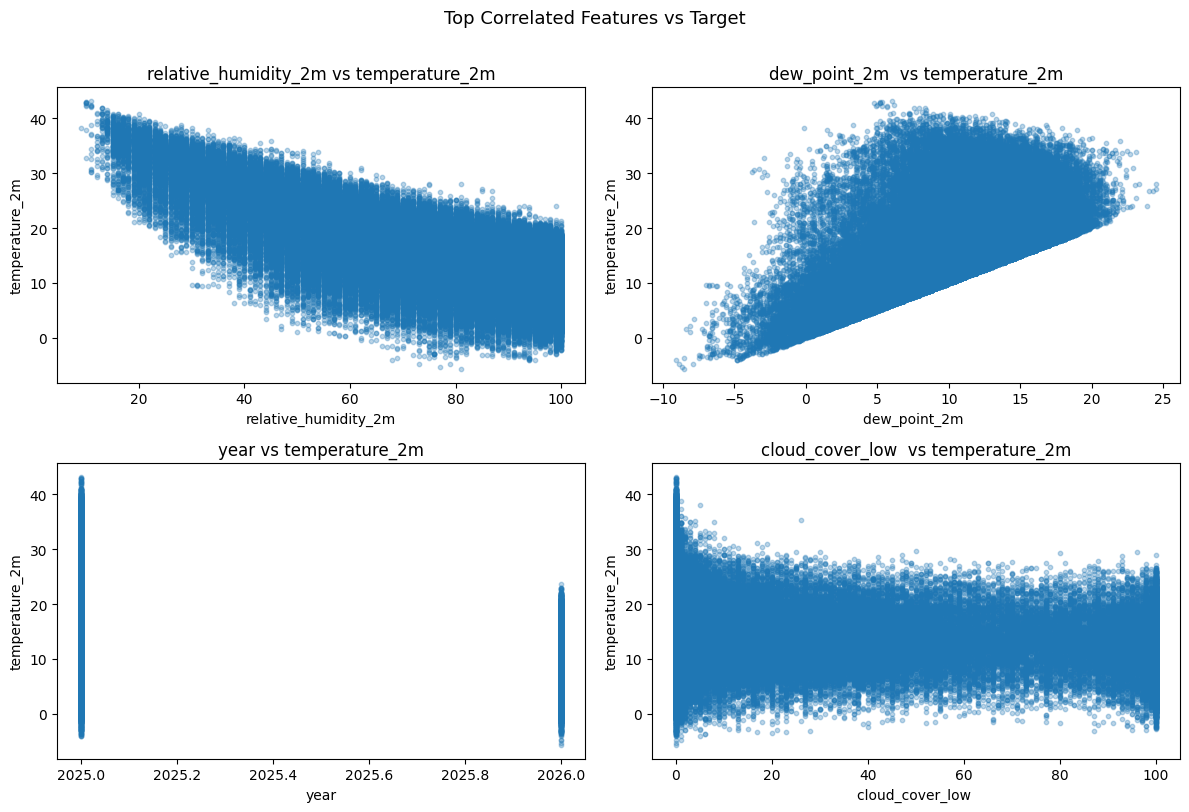

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Correlation Heatmap ---
corr_matrix = X.copy()
corr_matrix[target_col] = y
correlation = corr_matrix.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# --- 2. Top feature correlations with target ---
target_corr = correlation[target_col].drop(target_col).sort_values()

plt.figure(figsize=(10, 6))
colors = ["#d73027" if v > 0 else "#4575b4" for v in target_corr]
target_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Feature Correlations with {target_col.strip()}", fontsize=13)
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

# --- 3. Scatter plots for top 4 correlated features ---
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    axes[i].scatter(X[feat], y, alpha=0.3, s=10, color="#1f77b4")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(target_col.strip())
    axes[i].set_title(f"{feat} vs {target_col.strip()}")
plt.suptitle("Top Correlated Features vs Target", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


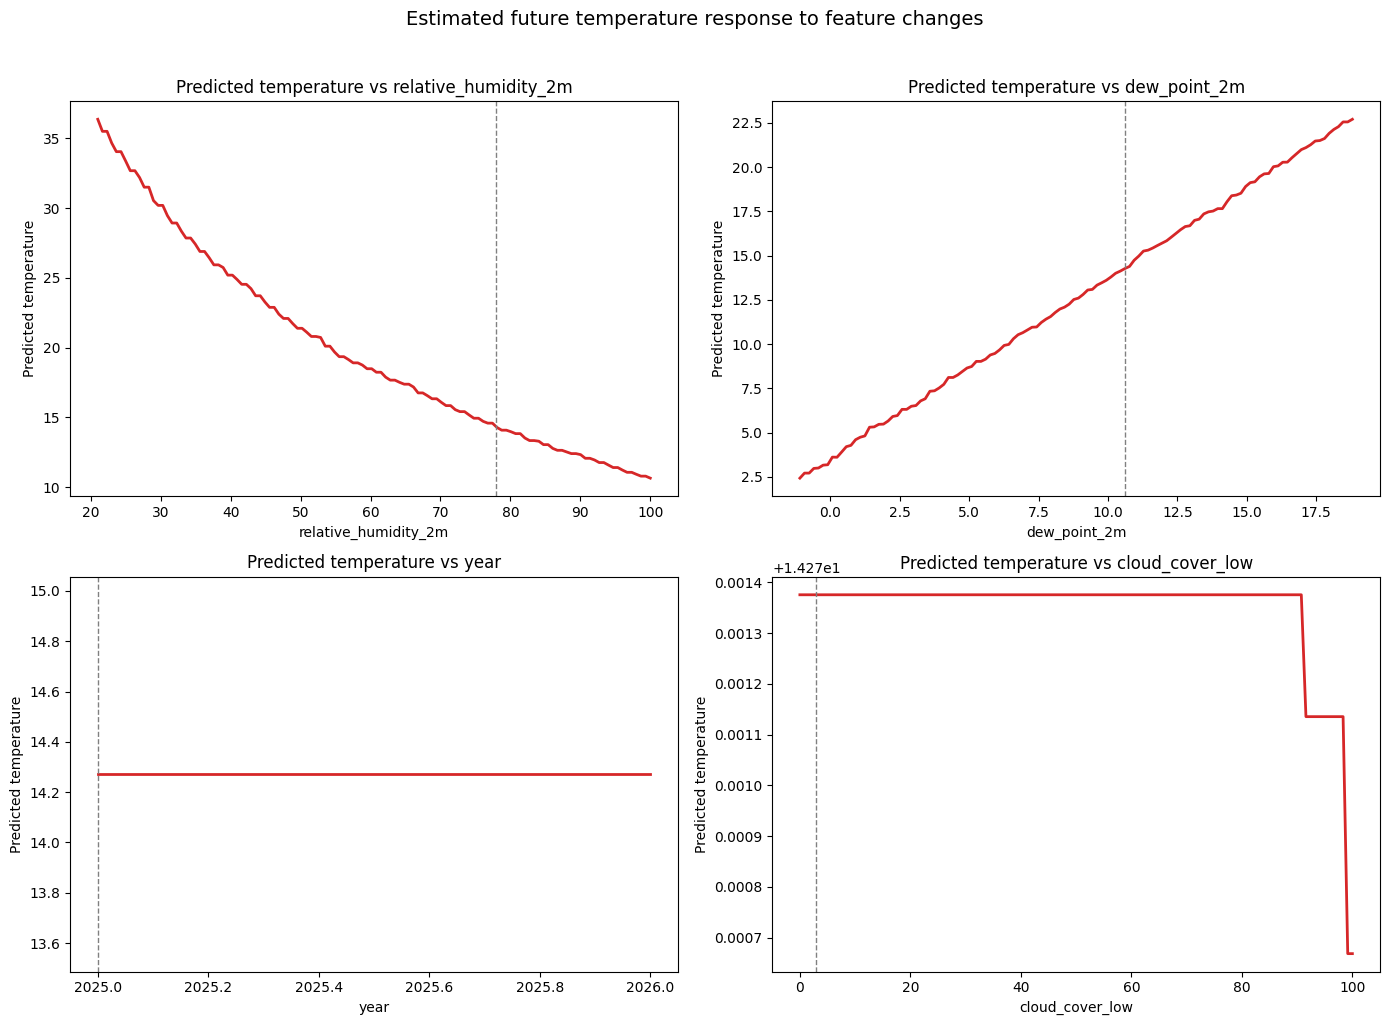

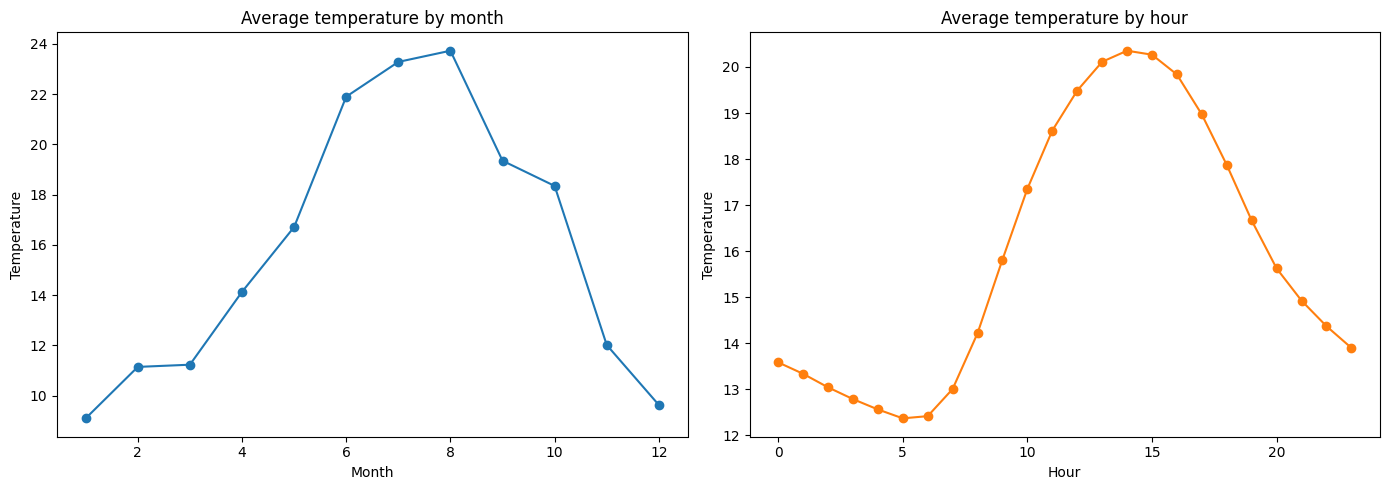

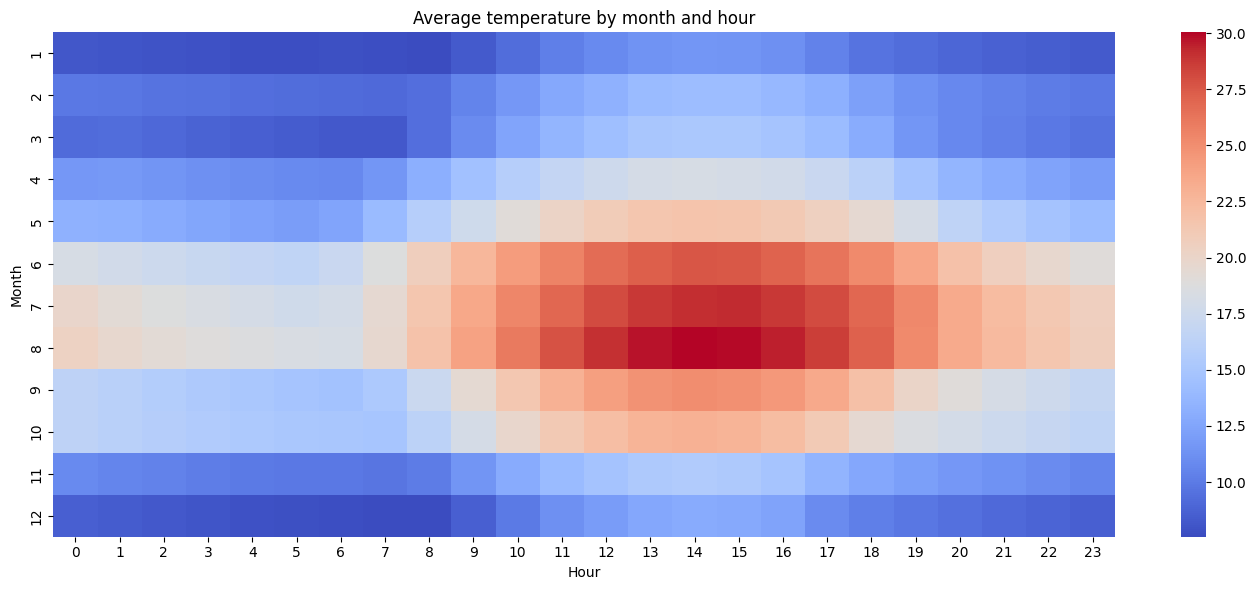

In [ ]:
# Model-based "future" sensitivity plots for the most correlated features
selected_features = top_features
baseline_row = X.median(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, selected_features):
    grid = np.linspace(X[feat].quantile(0.01), X[feat].quantile(0.99), 120)
    scenarios = pd.DataFrame([baseline_row] * len(grid))
    scenarios[feat] = grid

    pred_temp = model.predict(scaler.transform(scenarios[X.columns]))

    ax.plot(grid, pred_temp, color="#d62728", linewidth=2)
    ax.axvline(X[feat].median(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"Predicted temperature vs {feat.strip()}")
    ax.set_xlabel(feat.strip())
    ax.set_ylabel("Predicted temperature")

plt.suptitle("Estimated future temperature response to feature changes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Time-pattern graphs useful for future temperature trend interpretation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("month")[target_col].mean().plot(marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Average temperature by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Temperature")

df.groupby("hour")[target_col].mean().plot(marker="o", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Average temperature by hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Temperature")

plt.tight_layout()
plt.show()

# Heatmap of seasonal/hourly temperature behavior
temp_pivot = df.pivot_table(values=target_col, index="month", columns="hour", aggfunc="mean")

plt.figure(figsize=(14, 6))
sns.heatmap(temp_pivot, cmap="coolwarm", annot=False)
plt.title("Average temperature by month and hour")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

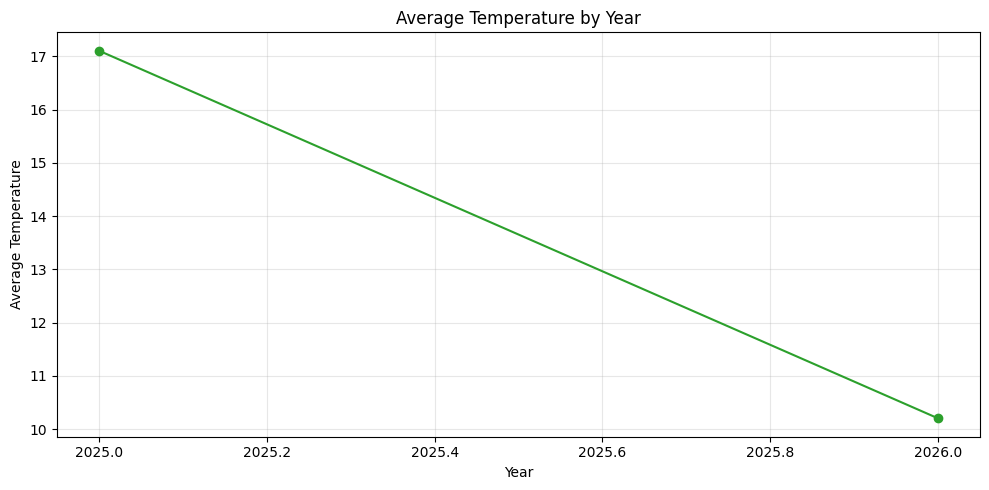

In [6]:
# Average temperature by year
if "year" in df.columns:
    yearly_avg_temp = df.groupby("year")[target_col].mean().sort_index()

    plt.figure(figsize=(10, 5))
    yearly_avg_temp.plot(marker="o", color="#2ca02c")
    plt.title("Average Temperature by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Temperature")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'year' is not available in df.")

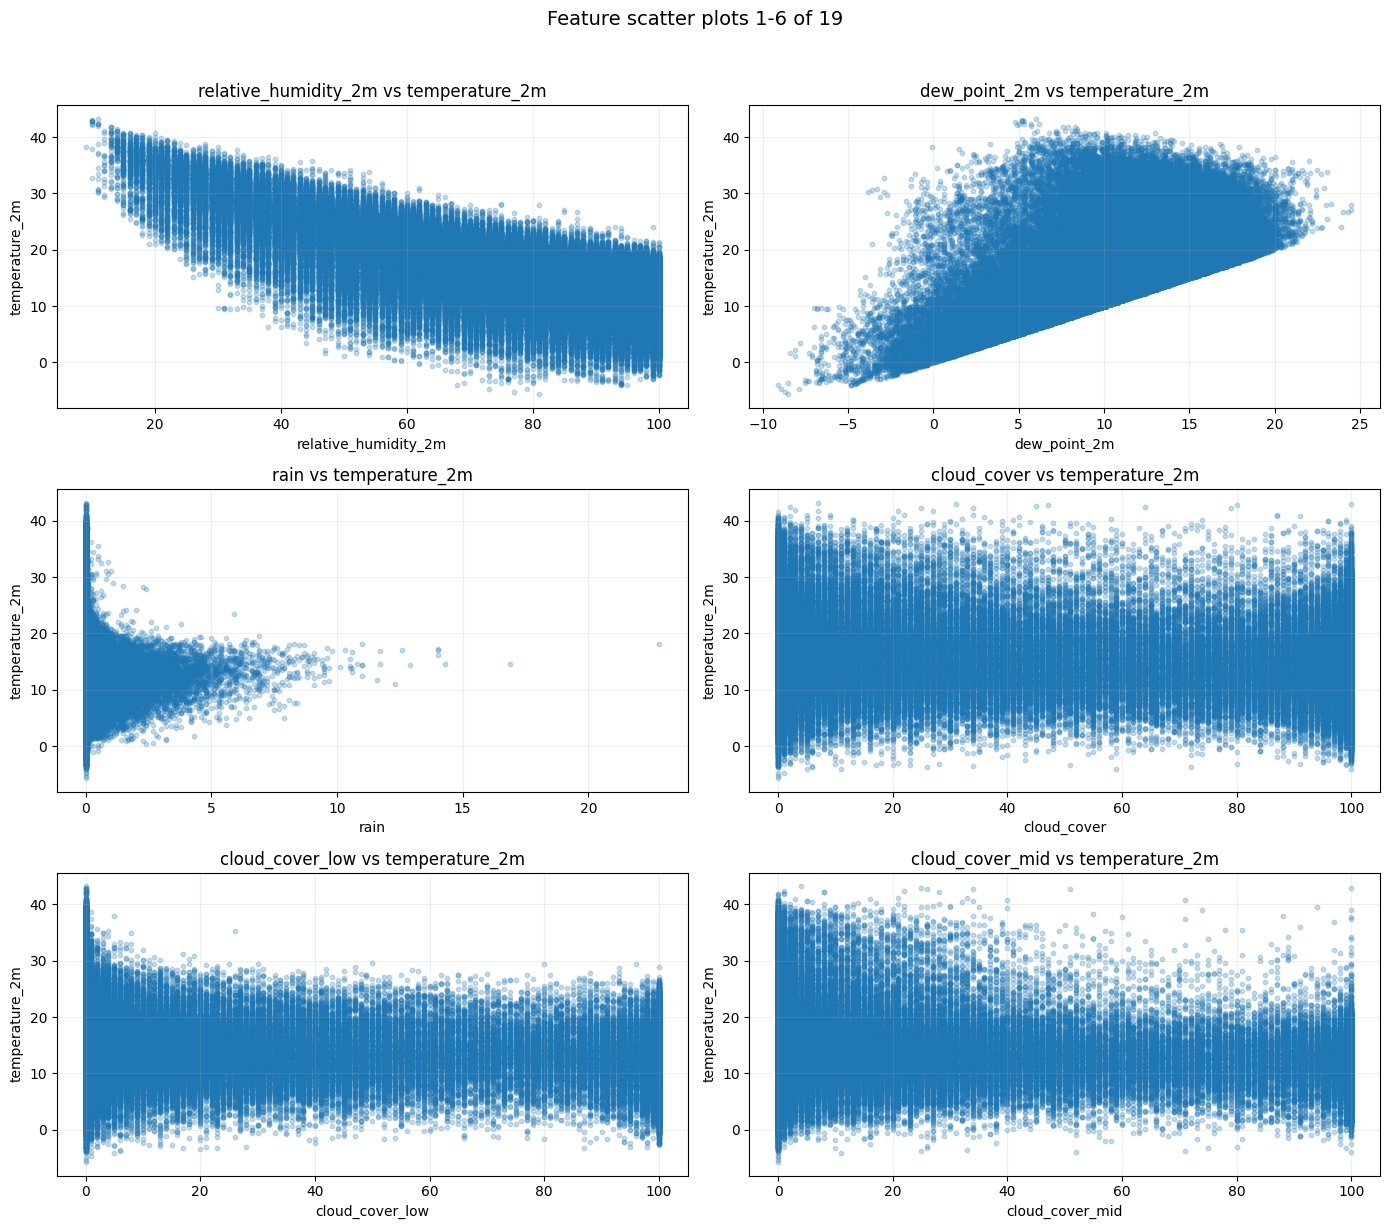

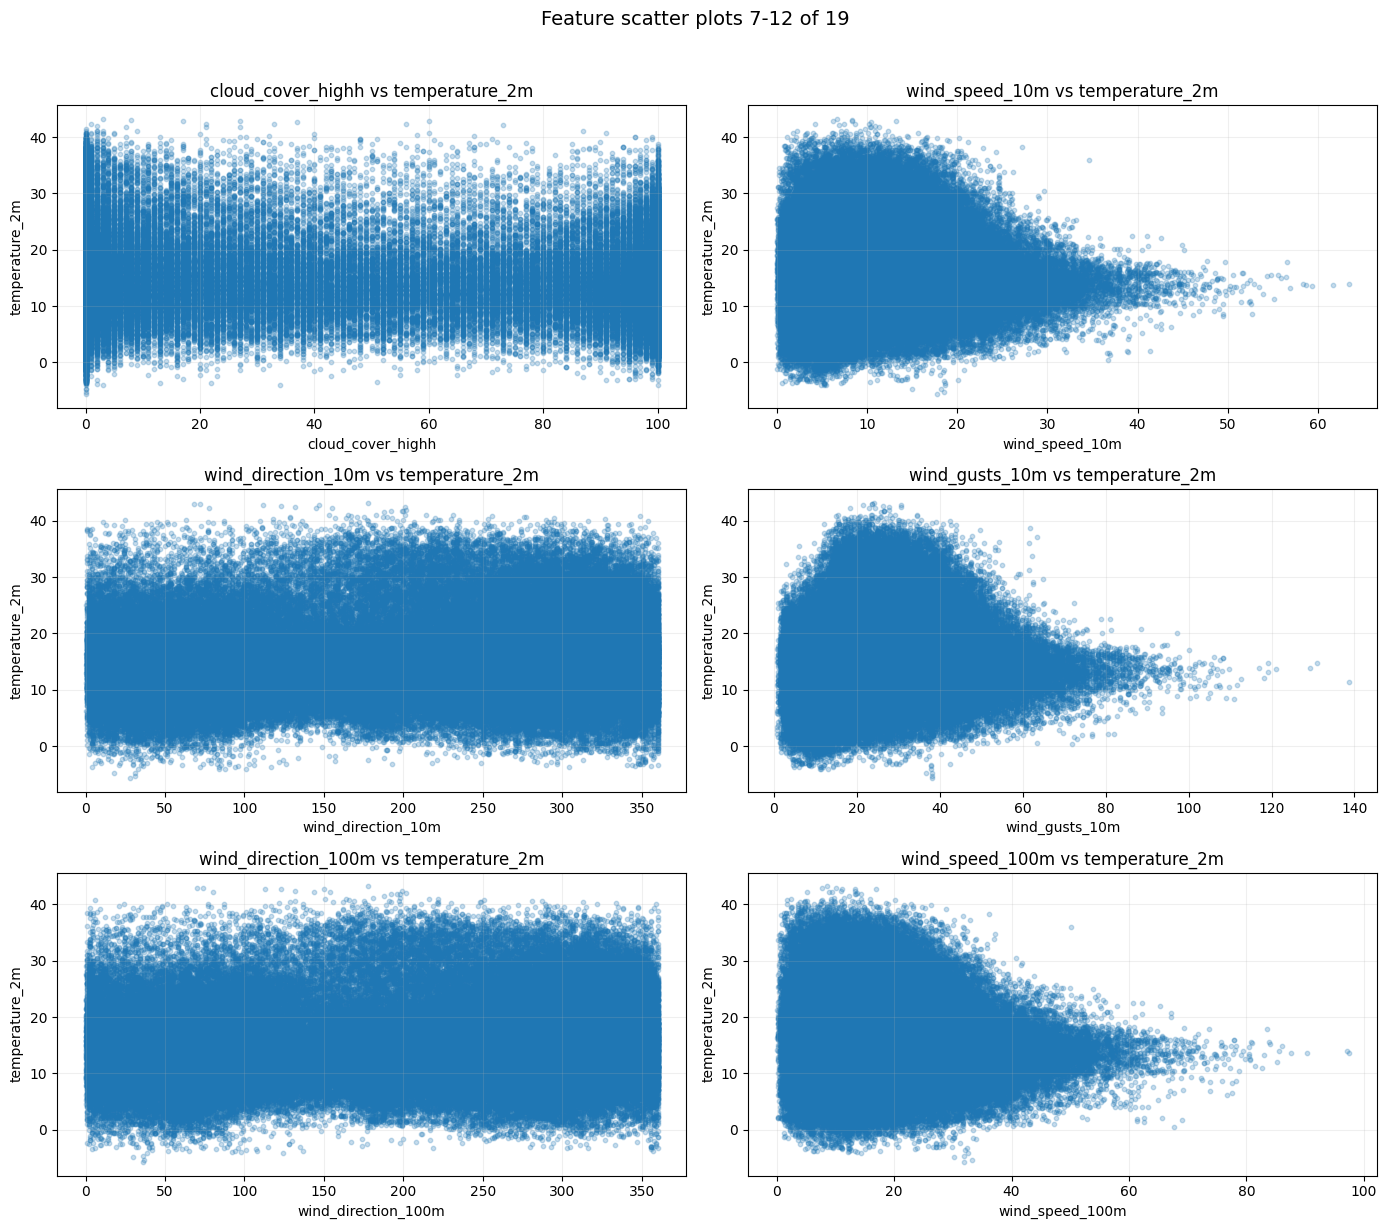

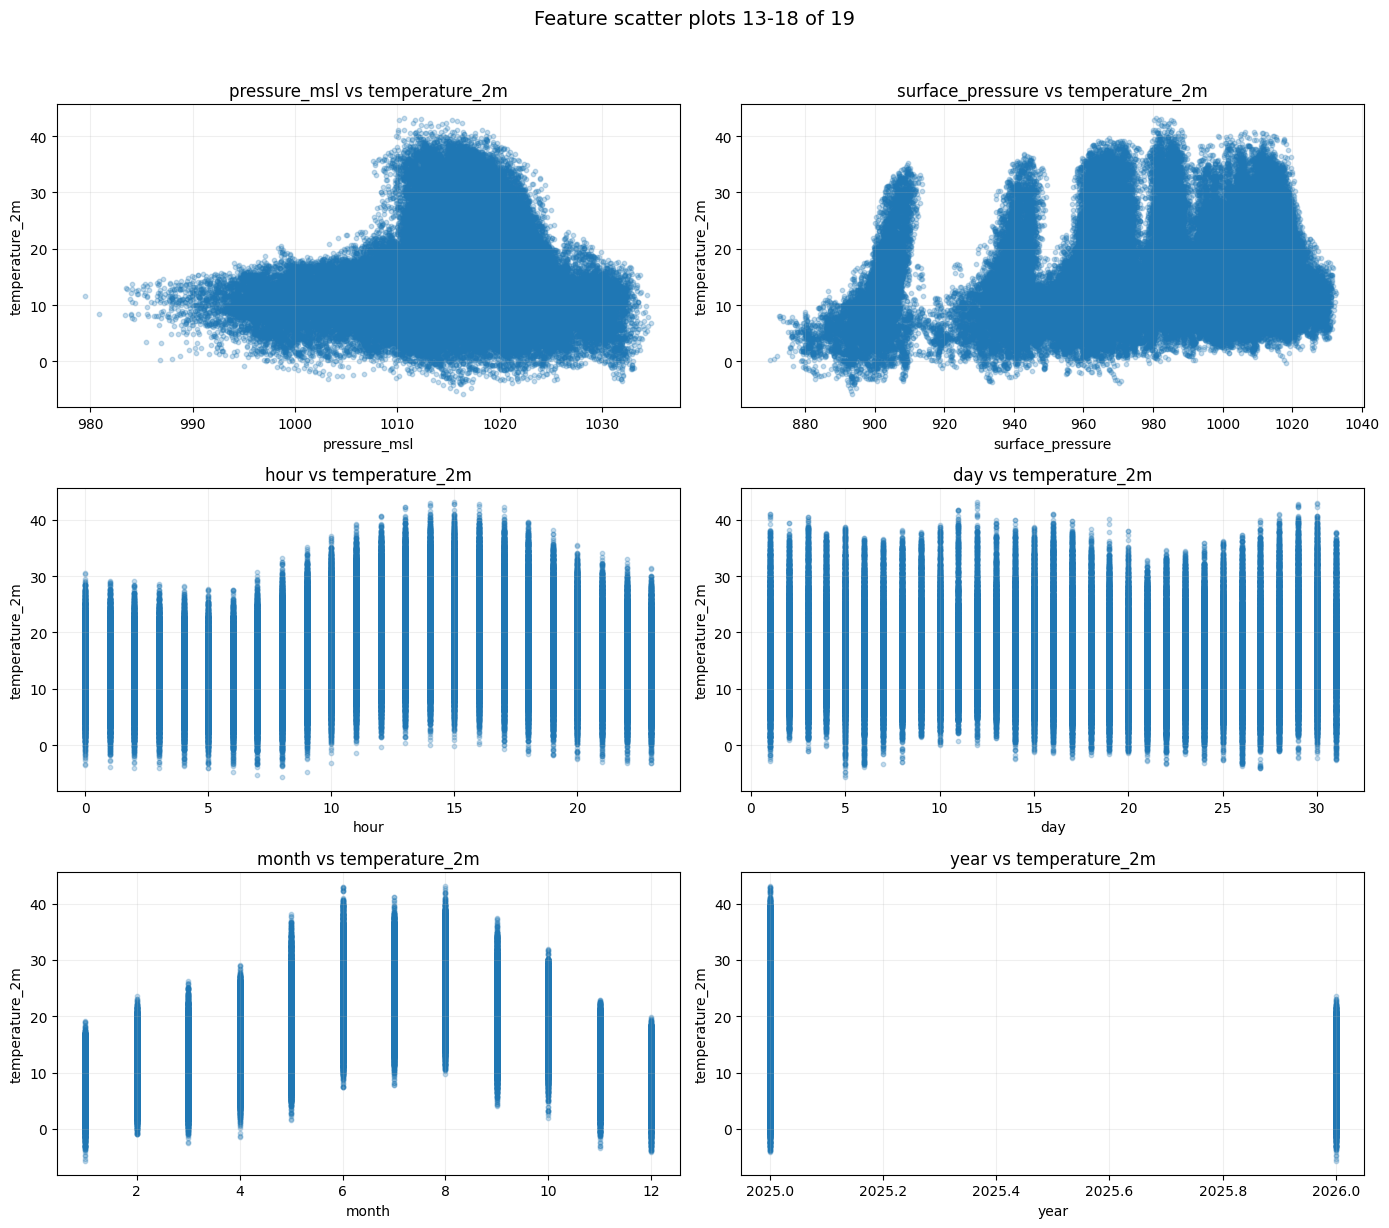

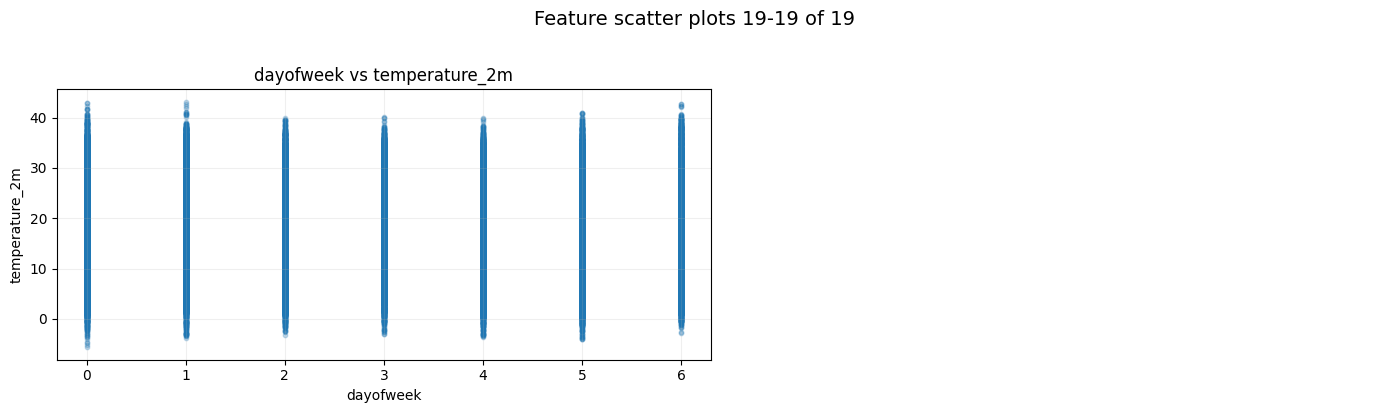

In [8]:
# Scatter plot for every numeric feature against the target
all_features = X.columns.tolist()
plots_per_figure = 6
n_cols = 2

for start_idx in range(0, len(all_features), plots_per_figure):
    batch_features = all_features[start_idx:start_idx + plots_per_figure]
    n_rows = int(np.ceil(len(batch_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, feat in zip(axes, batch_features):
        ax.scatter(X[feat], y, alpha=0.25, s=10, color="#1f77b4")
        ax.set_title(f"{feat.strip()} vs {target_col.strip()}")
        ax.set_xlabel(feat.strip())
        ax.set_ylabel(target_col.strip())
        ax.grid(alpha=0.2)

    for ax in axes[len(batch_features):]:
        ax.axis("off")

    fig.suptitle(
        f"Feature scatter plots {start_idx + 1}-{start_idx + len(batch_features)} of {len(all_features)}",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

Engineered features tested:
['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'humidity_cloud_interaction', 'gust_minus_wind_10m', 'wind_x_10m', 'wind_y_10m', 'pressure_gap', 'cloud_layer_sum', 'cloud_layer_std', 'rain_log1p']

Baseline vs engineered feature comparison:
                       model_version  feature_count       mae  \
0                           baseline             19  0.106950   
1  baseline_plus_engineered_features             31  0.112186   

   mae_change_vs_baseline  
0                0.000000  
1                0.005235  

Engineered feature importances:
month_cos                     4.067268e-03
pressure_gap                  2.559770e-04
month_sin                     1.578352e-05
wind_x_10m                    8.324493e-06
hour_cos                      1.833162e-06
wind_y_10m                    1.594916e-06
gust_minus_wind_10m           1.437695e-06
humidity_cloud_interaction    6.326505e-07
cloud_layer_sum               2.884706e-07
cloud_layer_std             

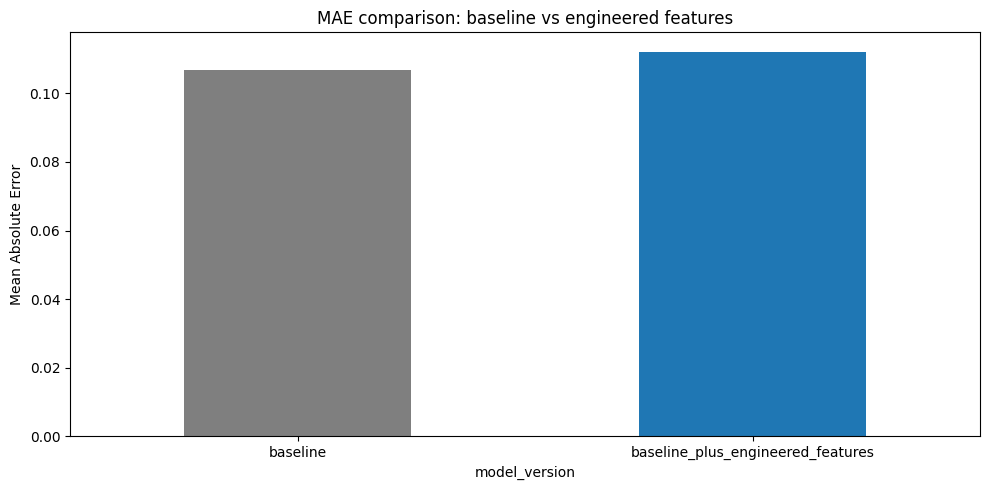

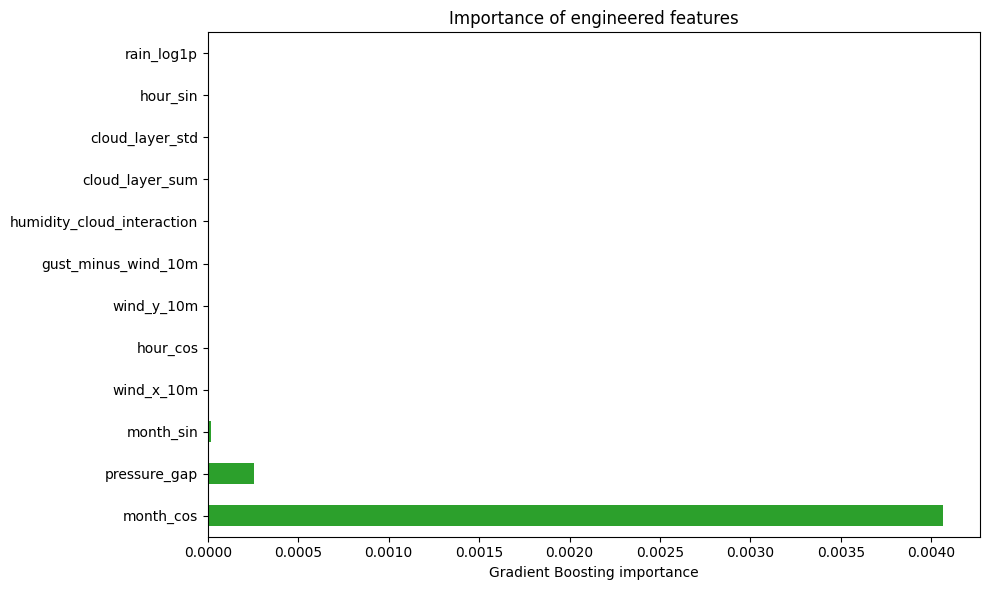

In [9]:
# Test custom engineered features inspired by the EDA graphs
eda_df = df.copy()
eda_df.columns = [str(col).strip() for col in eda_df.columns]
target_col_clean = target_col.strip()

baseline_X = eda_df.drop(columns=[target_col_clean]).select_dtypes(include=[np.number]).copy()
engineered_X = baseline_X.copy()
engineered_features = []

def add_engineered_feature(feature_name, feature_values):
    engineered_X[feature_name] = feature_values
    engineered_features.append(feature_name)

if "hour" in baseline_X.columns:
    add_engineered_feature("hour_sin", np.sin(2 * np.pi * baseline_X["hour"] / 24))
    add_engineered_feature("hour_cos", np.cos(2 * np.pi * baseline_X["hour"] / 24))

if "month" in baseline_X.columns:
    add_engineered_feature("month_sin", np.sin(2 * np.pi * baseline_X["month"] / 12))
    add_engineered_feature("month_cos", np.cos(2 * np.pi * baseline_X["month"] / 12))

if {"relative_humidity_2m", "cloud_cover"}.issubset(baseline_X.columns):
    add_engineered_feature(
        "humidity_cloud_interaction",
        baseline_X["relative_humidity_2m"] * baseline_X["cloud_cover"]
    )

if {"wind_speed_10m", "wind_gusts_10m"}.issubset(baseline_X.columns):
    add_engineered_feature(
        "gust_minus_wind_10m",
        baseline_X["wind_gusts_10m"] - baseline_X["wind_speed_10m"]
    )

if {"wind_speed_10m", "wind_direction_10m"}.issubset(baseline_X.columns):
    direction_radians = np.deg2rad(baseline_X["wind_direction_10m"])
    add_engineered_feature("wind_x_10m", baseline_X["wind_speed_10m"] * np.cos(direction_radians))
    add_engineered_feature("wind_y_10m", baseline_X["wind_speed_10m"] * np.sin(direction_radians))

if {"pressure_msl", "surface_pressure"}.issubset(baseline_X.columns):
    add_engineered_feature(
        "pressure_gap",
        baseline_X["pressure_msl"] - baseline_X["surface_pressure"]
    )

cloud_layer_cols = [
    col for col in ["cloud_cover_low", "cloud_cover_mid", "cloud_cover_highh"] if col in baseline_X.columns
]
if len(cloud_layer_cols) >= 2:
    add_engineered_feature("cloud_layer_sum", baseline_X[cloud_layer_cols].sum(axis=1))
    add_engineered_feature("cloud_layer_std", baseline_X[cloud_layer_cols].std(axis=1))

if "rain" in baseline_X.columns:
    add_engineered_feature("rain_log1p", np.log1p(baseline_X["rain"]))

feature_target = eda_df[target_col_clean]

baseline_train_X, baseline_test_X, baseline_train_y, baseline_test_y = train_test_split(
    baseline_X, feature_target, test_size=0.2, random_state=42
)

engineered_train_X, engineered_test_X, engineered_train_y, engineered_test_y = train_test_split(
    engineered_X, feature_target, test_size=0.2, random_state=42
)

baseline_scaler = StandardScaler()
baseline_train_X_scaled = baseline_scaler.fit_transform(baseline_train_X)
baseline_test_X_scaled = baseline_scaler.transform(baseline_test_X)

engineered_scaler = StandardScaler()
engineered_train_X_scaled = engineered_scaler.fit_transform(engineered_train_X)
engineered_test_X_scaled = engineered_scaler.transform(engineered_test_X)

baseline_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
baseline_model.fit(baseline_train_X_scaled, baseline_train_y)
baseline_pred = baseline_model.predict(baseline_test_X_scaled)
baseline_mae = mean_absolute_error(baseline_test_y, baseline_pred)

engineered_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
engineered_model.fit(engineered_train_X_scaled, engineered_train_y)
engineered_pred = engineered_model.predict(engineered_test_X_scaled)
engineered_mae = mean_absolute_error(engineered_test_y, engineered_pred)

comparison_df = pd.DataFrame(
    {
        "model_version": ["baseline", "baseline_plus_engineered_features"],
        "feature_count": [baseline_X.shape[1], engineered_X.shape[1]],
        "mae": [baseline_mae, engineered_mae],
    }
)
comparison_df["mae_change_vs_baseline"] = comparison_df["mae"] - baseline_mae

engineered_importance = pd.Series(
    engineered_model.feature_importances_,
    index=engineered_X.columns
)
engineered_feature_importance = engineered_importance.reindex(engineered_features).dropna().sort_values(ascending=False)

print("Engineered features tested:")
print(engineered_features)
print("\nBaseline vs engineered feature comparison:")
print(comparison_df)
print("\nEngineered feature importances:")
print(engineered_feature_importance)

plt.figure(figsize=(10, 5))
comparison_plot = comparison_df.set_index("model_version")["mae"]
comparison_plot.plot(kind="bar", color=["#7f7f7f", "#1f77b4"])
plt.title("MAE comparison: baseline vs engineered features")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if not engineered_feature_importance.empty:
    plt.figure(figsize=(10, 6))
    engineered_feature_importance.plot(kind="barh", color="#2ca02c")
    plt.title("Importance of engineered features")
    plt.xlabel("Gradient Boosting importance")
    plt.tight_layout()
    plt.show()

Rows -> train: 126488, val: 15811, test: 15812
Engineered feature count: 33

Linear Regression (expanded features)
Validation MAE:  2.3165
Validation RMSE: 2.9456
Validation R2:   0.4399
Test MAE:        2.0881
Test RMSE:       2.6101
Test R2:         0.5130

Top 15 absolute coefficients:
temp_roll_mean_6        4.716944
relative_humidity_2m   -0.908945
dew_point_2m            0.650728
temp_roll_std_6         0.371633
month_cos              -0.347400
month_sin              -0.332019
hour_cos               -0.327305
humidity_x_dew          0.321174
wind_speed_100m        -0.297524
wind_gusts_10m          0.239177
pressure_gap            0.164634
surface_pressure       -0.151722
hour_sin               -0.148386
wind_y_10m              0.142803
temp_roll_mean_3       -0.141352
dtype: float64


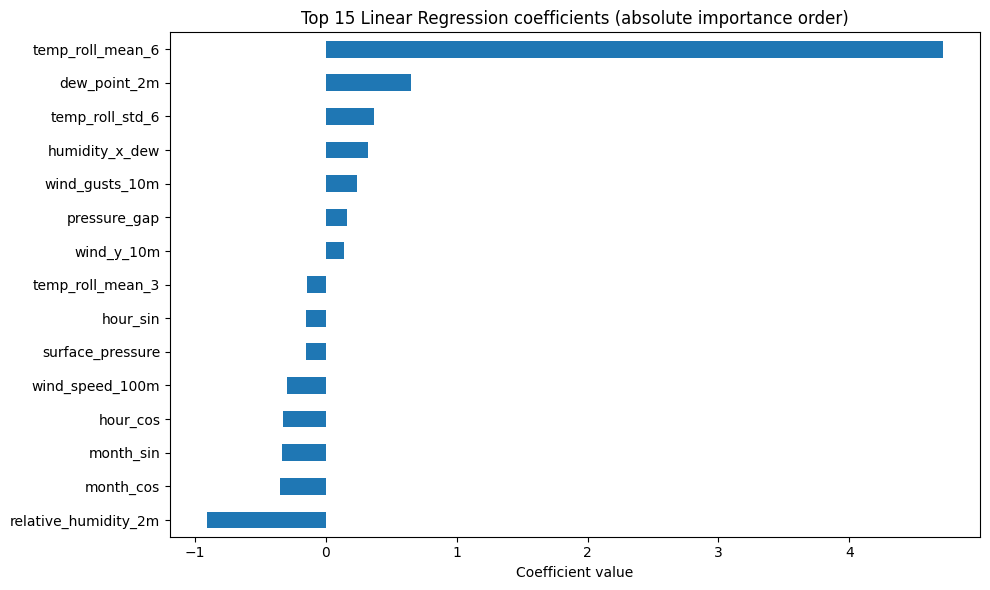

In [13]:
# Experiment with richer feature engineering using Linear Regression only
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

exp_df = pd.read_csv("../metherology_dataset.csv")
exp_df.columns = [str(c).strip() for c in exp_df.columns]

if "time" not in exp_df.columns:
    raise ValueError("This cell expects a 'time' column in the source CSV.")

exp_df["time"] = pd.to_datetime(exp_df["time"], errors="coerce")
exp_df = exp_df.sort_values("time").reset_index(drop=True)

target_name = "temperature_2m"
if target_name not in exp_df.columns:
    raise KeyError(f"Missing target column '{target_name}'. Available: {list(exp_df.columns)}")

# Convert non-time columns to numeric
for col in exp_df.columns:
    if col != "time":
        exp_df[col] = pd.to_numeric(exp_df[col], errors="coerce")

# Base numeric weather features (excluding target)
base_X = exp_df.drop(columns=["time", target_name], errors="ignore").copy()
base_X = base_X.select_dtypes(include=[np.number])

# Time features
base_X["hour"] = exp_df["time"].dt.hour
base_X["dayofweek"] = exp_df["time"].dt.dayofweek
base_X["month"] = exp_df["time"].dt.month

# Expanded feature set
X_expanded = base_X.copy()
X_expanded["hour_sin"] = np.sin(2 * np.pi * X_expanded["hour"] / 24)
X_expanded["hour_cos"] = np.cos(2 * np.pi * X_expanded["hour"] / 24)
X_expanded["dow_sin"] = np.sin(2 * np.pi * X_expanded["dayofweek"] / 7)
X_expanded["dow_cos"] = np.cos(2 * np.pi * X_expanded["dayofweek"] / 7)
X_expanded["month_sin"] = np.sin(2 * np.pi * X_expanded["month"] / 12)
X_expanded["month_cos"] = np.cos(2 * np.pi * X_expanded["month"] / 12)

if {"relative_humidity_2m", "dew_point_2m"}.issubset(exp_df.columns):
    X_expanded["humidity_x_dew"] = exp_df["relative_humidity_2m"] * exp_df["dew_point_2m"]

if {"wind_speed_10m", "wind_direction_10m"}.issubset(exp_df.columns):
    rad = np.deg2rad(exp_df["wind_direction_10m"] % 360)
    X_expanded["wind_x_10m"] = exp_df["wind_speed_10m"] * np.cos(rad)
    X_expanded["wind_y_10m"] = exp_df["wind_speed_10m"] * np.sin(rad)

if {"pressure_msl", "surface_pressure"}.issubset(exp_df.columns):
    X_expanded["pressure_gap"] = exp_df["pressure_msl"] - exp_df["surface_pressure"]

# Temperature dynamics (safe for forecasting because they only use past values)
temp_series = exp_df[target_name]
X_expanded["temp_lag_1"] = temp_series.shift(1)
X_expanded["temp_lag_3"] = temp_series.shift(3)
X_expanded["temp_lag_6"] = temp_series.shift(6)
X_expanded["temp_roll_mean_3"] = temp_series.shift(1).rolling(3).mean()
X_expanded["temp_roll_mean_6"] = temp_series.shift(1).rolling(6).mean()
X_expanded["temp_roll_std_6"] = temp_series.shift(1).rolling(6).std()

# Remove unusable columns and build next-step target
X_expanded = X_expanded.dropna(axis=1, how="all")
y_expanded = temp_series.shift(-1)

experiment_df = X_expanded.copy()
experiment_df["target"] = y_expanded
experiment_df = experiment_df.dropna(subset=["target"]).copy()

if len(experiment_df) < 20:
    raise ValueError(
        f"Not enough rows after preprocessing ({len(experiment_df)}). "
        "Try reducing lag/rolling features or checking source data completeness."
    )

X_final = experiment_df.drop(columns=["target"])
y_final = experiment_df["target"]

# Chronological split: 80/10/10 with safety guards
n = len(experiment_df)
train_end = max(1, int(n * 0.8))
val_end = max(train_end + 1, int(n * 0.9))
if val_end >= n:
    val_end = n - 1

if train_end <= 0 or val_end <= train_end or (n - val_end) <= 0:
    raise ValueError(
        f"Invalid split sizes for n={n}. Computed train_end={train_end}, val_end={val_end}."
    )

X_train_exp = X_final.iloc[:train_end]
X_val_exp = X_final.iloc[train_end:val_end]
X_test_exp = X_final.iloc[val_end:]
y_train_exp = y_final.iloc[:train_end]
y_val_exp = y_final.iloc[train_end:val_end]
y_test_exp = y_final.iloc[val_end:]

# Impute then scale for linear regression
imputer_exp = SimpleImputer(strategy="median")
X_train_exp_imputed = imputer_exp.fit_transform(X_train_exp)
X_val_exp_imputed = imputer_exp.transform(X_val_exp)
X_test_exp_imputed = imputer_exp.transform(X_test_exp)

scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp_imputed)
X_val_exp_scaled = scaler_exp.transform(X_val_exp_imputed)
X_test_exp_scaled = scaler_exp.transform(X_test_exp_imputed)

lr_model = LinearRegression()
lr_model.fit(X_train_exp_scaled, y_train_exp)

pred_val = lr_model.predict(X_val_exp_scaled)
pred_test = lr_model.predict(X_test_exp_scaled)

val_mae = mean_absolute_error(y_val_exp, pred_val)
val_rmse = mean_squared_error(y_val_exp, pred_val) ** 0.5
val_r2 = r2_score(y_val_exp, pred_val)

test_mae = mean_absolute_error(y_test_exp, pred_test)
test_rmse = mean_squared_error(y_test_exp, pred_test) ** 0.5
test_r2 = r2_score(y_test_exp, pred_test)

print(f"Rows -> train: {len(X_train_exp)}, val: {len(X_val_exp)}, test: {len(X_test_exp)}")
print(f"Engineered feature count: {X_final.shape[1]}")
print("\nLinear Regression (expanded features)")
print(f"Validation MAE:  {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation R2:   {val_r2:.4f}")
print(f"Test MAE:        {test_mae:.4f}")
print(f"Test RMSE:       {test_rmse:.4f}")
print(f"Test R2:         {test_r2:.4f}")

coef_series = pd.Series(lr_model.coef_, index=X_final.columns).sort_values(key=np.abs, ascending=False)
print("\nTop 15 absolute coefficients:")
print(coef_series.head(15))

plt.figure(figsize=(10, 6))
coef_series.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 Linear Regression coefficients (absolute importance order)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()